In [1]:
import os

import matplotlib
import numpy as np
from gvxrPython3 import gvxr

# CT reconstruction
from gvxrPython3.utils import (
    applyFiltration,
    loadSpectrum,
)
from matplotlib import pyplot as plt

# Configure matplotlib graph
font = {
    "family" : "serif",
     "size"   : 25,
}

matplotlib.rc("font", **font)

# Uncomment the line below to use LaTeX fonts
# matplotlib.rc('text', usetex=True)

spekpy is not install, you won't be able to load a beam spectrum using spekpy
xpecgen is not install, you won't be able to load a beam spectrum using xpecgen


### Global variables

In [2]:
OUTPUT_PATH = "../../output_data/beam-hardening/"

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

### Create an OpenGL context

In [3]:
gvxr.createOpenGLContext()

Thu Apr 30 15:48:20 2026 ---- Create window (ID: -1)
Thu Apr 30 15:48:20 2026 ---- Request an interactive OpenGL context
Thu Apr 30 15:48:20 2026 ---- Initialise GLFW
Thu Apr 30 15:48:20 2026 (WW) GLFW error: X11: The DISPLAY environment variable is missing
Thu Apr 30 15:48:20 2026 (WW) Cannot initialise GLFW.
Thu Apr 30 15:48:20 2026 (WW) Could not create a context
Thu Apr 30 15:48:20 2026 ---- Request a EGL context
Thu Apr 30 15:48:20 2026 ---- Query the number of EGL devices
Thu Apr 30 15:48:20 2026 ---- Success
Thu Apr 30 15:48:20 2026 ---- Detected 4 EGL devices.
Thu Apr 30 15:48:20 2026 ---- Print the details here of every EGL device.
Thu Apr 30 15:48:20 2026 ---- Success
Thu Apr 30 15:48:20 2026 ---- Device 1/4:
Thu Apr 30 15:48:20 2026 ---- 	Device Extensions: EGL_NV_device_cuda EGL_EXT_device_drm EGL_EXT_device_drm_render_node EGL_EXT_device_query_name EGL_EXT_device_persistent_id
Thu Apr 30 15:48:20 2026 ---- 	EGL DRM device file: /dev/dri/card1
Thu Apr 30 15:48:20 2026 ---- 

### Create an iron cylinder as main object source

###  Set up the detector

In [4]:
# Detector Position and direction
gvxr.setDetectorPosition(
    20.0, 0.0, 0.0,
    "cm"
)

gvxr.setDetectorUpVector(0, 0, -1)

# Detector Pixel definitions
gvxr.setDetectorNumberOfPixels(640, 640)

gvxr.setDetectorPixelSize(
    0.5, 0.5,
    "mm"
)

### Create a source

In [5]:
# Source position
gvxr.setSourcePosition(
    -20.0,  0.0, 0.0,
    "cm",
)

# Source type
gvxr.useParallelBeam()    # For a parallel source

In [6]:
def getPolySpectrum(
        tube_voltage_kV: float,
        filters=None,
        tube_angle_in_deg: float=12,
        mAs = None,
        unit = "keV",
) -> dict:

    gvxr.clearFiltration()
    gvxr.setVoltage(tube_voltage_kV, "kV")
    gvxr.setTubeAngle(tube_angle_in_deg)

    if mAs:
        gvxr.setmAs(mAs)
    else:
        gvxr.setmAs(-1)

    if filters:
        applyFiltration(filters)

    energy_bins = gvxr.getEnergyBins(unit)

    photon_count = np.array(
        gvxr.getPhotonCountsPerCm2At1m(),
        dtype=np.single
    )

    photon_count /= photon_count.sum()

    return loadSpectrum(energy_bins, photon_count, unit, False)

In [7]:
tube_voltage_kV = 100
tube_angle_degrees = 12
max_number_of_energy_bins = 100

# ------------
# No filter
# ------------
no_filter_hist = getPolySpectrum(
    tube_voltage_kV,
    filters=None,
    tube_angle_in_deg=12,
)
no_filter_bins, no_filter_photons = zip(*no_filter_hist.items(), strict=False)

# ------------
# Al filters
# ------------
al_half_mm_filter_hist = getPolySpectrum(
    tube_voltage_kV,
    filters=[["Al", 0.5, "mm"]],
    tube_angle_in_deg=12,
)

al_1_mm_filter_hist = getPolySpectrum(
    tube_voltage_kV,
    filters=[["Al", 1.0, "mm"]],
    tube_angle_in_deg=12,
)

al_half_mm_filter_bins, al_half_mm_filter_photons = zip(*al_half_mm_filter_hist.items(), strict=False)
al_1_mm_filter_bins, al_1_mm_filter_photons = zip(*al_1_mm_filter_hist.items(), strict=False)

# ------------
# Cu filters
# ------------
cu_half_mm_filter_hist = getPolySpectrum(
    tube_voltage_kV,
    filters=[["Cu", 0.5, "mm"]],
    tube_angle_in_deg=12,
)

cu_1_mm_filter_hist = getPolySpectrum(
    tube_voltage_kV,
    filters=[["Cu", 1.0, "mm"]],
    tube_angle_in_deg=12,
)

cu_half_mm_filter_bins, cu_half_mm_filter_photons = zip(*cu_half_mm_filter_hist.items(), strict=False)
cu_1_mm_filter_bins, cu_1_mm_filter_photons = zip(*cu_1_mm_filter_hist.items(), strict=False)

# ------------
# Sn filters
# ------------
sn_half_mm_filter_hist = getPolySpectrum(
    tube_voltage_kV,
    filters=[["Sn", 0.5, "mm"]],
    tube_angle_in_deg=12,
)

sn_1_mm_filter_hist = getPolySpectrum(
    tube_voltage_kV,
    filters=[["Sn", 1.0, "mm"]],
    tube_angle_in_deg=12,
)

sn_half_mm_filter_bins, sn_half_mm_filter_photons = zip(*sn_half_mm_filter_hist.items(), strict=False)
sn_1_mm_filter_bins, sn_1_mm_filter_photons = zip(*sn_1_mm_filter_hist.items(), strict=False)

Thu Apr 30 15:48:20 2026 ---- Initialise the renderer with 32 bits per floating-point numbers in GPU memory
Thu Apr 30 15:48:21 2026 (WW) addEnergyBinToSpectrum is deprecated. It will be removed in a future release. Choose addEnergyBinToSpectrumPerPixelAtSDD or addEnergyBinToSpectrumPerCm2At1m. Note that addEnergyBinToSpectrum and addEnergyBinToSpectrumPerPixelAtSDD are equivalent.


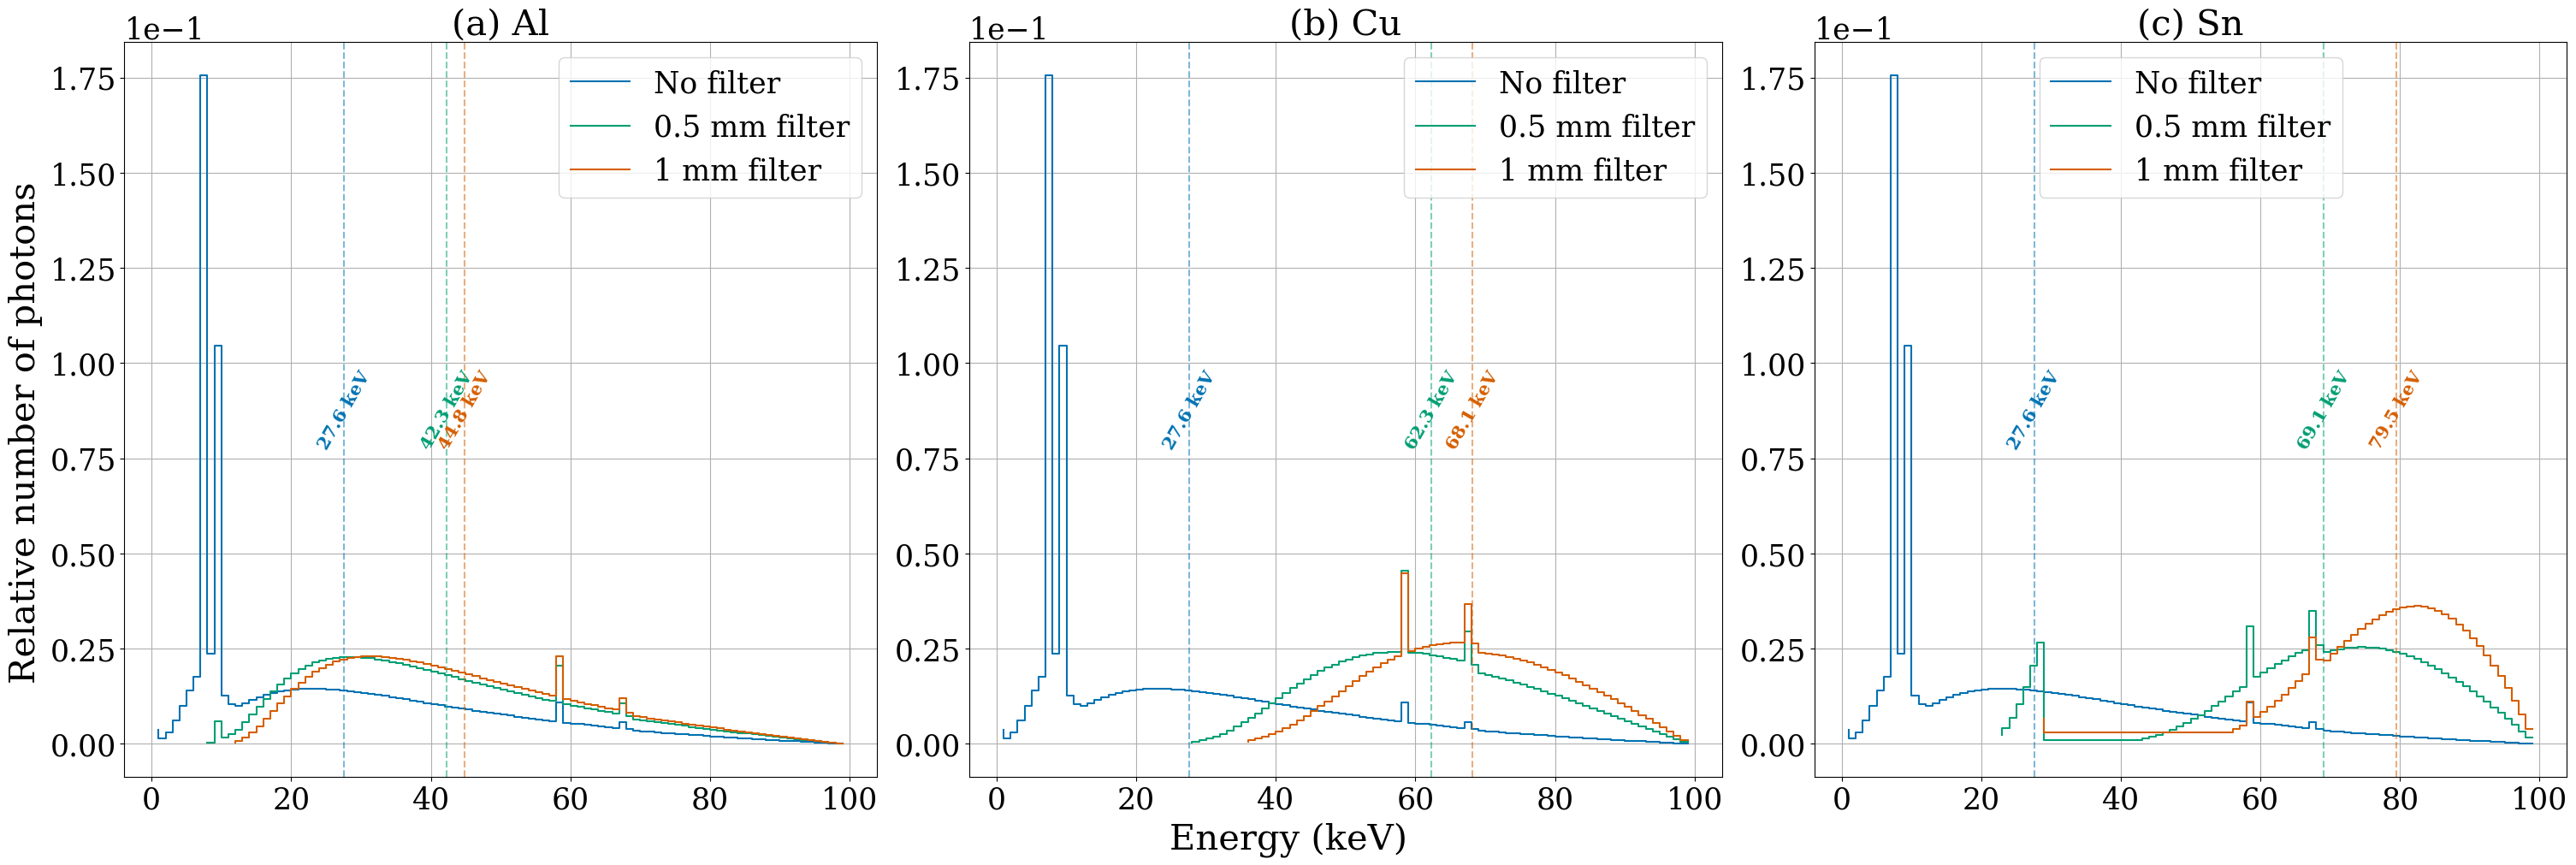

In [10]:
plt.close()

# Plot all the spectra
subplots_data = [
    {
        "title": "(a) Al",
        "curves": [
            (no_filter_bins, no_filter_photons, "No filter"),
            (al_half_mm_filter_bins, al_half_mm_filter_photons, "0.5 mm filter"),
            (al_1_mm_filter_bins, al_1_mm_filter_photons, "1 mm filter"),
        ],
    },
    {
        "title": "(b) Cu",
        "curves": [
            (no_filter_bins, no_filter_photons, "No filter"),
            (cu_half_mm_filter_bins, cu_half_mm_filter_photons, "0.5 mm filter"),
            (cu_1_mm_filter_bins, cu_1_mm_filter_photons, "1 mm filter"),
        ],
    },
    {
        "title": "(c) Sn",
        "curves": [
            (no_filter_bins, no_filter_photons, "No filter"),
            (sn_half_mm_filter_bins, sn_half_mm_filter_photons, "0.5 mm filter"),
            (sn_1_mm_filter_bins, sn_1_mm_filter_photons, "1 mm filter"),
        ],
    },
]

plt.style.use("seaborn-v0_8-colorblind")

fig, axes = plt.subplots(1, 3, figsize=(30, 10), constrained_layout=True)
fig.supxlabel("Energy (keV)")
fig.supylabel("Relative number of photons")

for axis, data in zip(axes, subplots_data, strict=False):
    axis.set_title(data["title"])
    axis.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    for x, y, label in data["curves"]:
        (line,) = axis.step(x, y, label=label)
        curve_colour = line.get_color()
        centroid = np.average(x, weights=y)

        axis.axvline(centroid, linestyle="--", alpha=0.5, color=curve_colour, label="_nolegend_")

        y_min, y_max = axis.get_ylim()
        y_mid = (y_min + y_max) / 2
        axis.text(
            centroid, y_mid,
            f"{centroid:.1f} keV",
            color=curve_colour,
            rotation=60,
            va="center",
            ha="center",
            fontsize=15,
            fontweight="bold",
            # bbox={
            #     "facecolor": axis.get_facecolor(),
            #     "edgecolor": "none",
            #     "pad": 3,
            # },
        )

    axis.legend()
    axis.grid(True)

fig.canvas.draw()

fig_to_print = plt.gcf()

fig_to_print.savefig(
    "poly-spectrum-comparison.pdf",
    transparent=False,
    facecolor="white",
)

plt.show()